# CO₂ hydrate calculations with NeqSim: brines, inhibitors and drilling-fluid examples

**A hands-on tutorial on setting up, running and interpreting NeqSim calculations.**

[Open in Google Colab](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/codex/co2-hydrate-brines-drilling-fluids-20260908/notebooks/flowassurance/co2_hydrate_brines_and_drilling_fluids.ipynb) · [Back to the examples catalog](../examples_of_NeqSim_in_Colab.ipynb)

Learn how to define a fluid composition, calculate a hydrate equilibrium temperature, build
pressure–temperature curves and inspect the returned phase state. Extend the same workflow
to salt mixtures, MEG, gas composition, aqueous chemistry and comparison with measured data.

The examples use public or explicitly synthetic inputs. Executed result tables, figures and
numerical diagnostics are retained so you can compare your own run with the saved outputs.
The drilling-fluid example demonstrates how a brine model can support an empirical correction;
it is not a validated model of an arbitrary complete drilling fluid.

**Open-source use.** NeqSim and its Python interface use Apache License 2.0, which permits use,
modification and commercial applications without a licence fee. Redistribution requires the
applicable licence, attribution notices and change notices. Check separate terms for any
external data or dependencies you add.

License sources: [NeqSim LICENSE](https://github.com/equinor/neqsim/blob/master/LICENSE),
[Python interface](https://github.com/equinor/neqsim-python),
[Apache 2.0 terms](https://www.apache.org/licenses/LICENSE-2.0).

## 1. Learning objectives and demonstrated capabilities

| Question | Executable demonstration | Interpretation boundary |
|---|---|---|
| How does salinity move the CO₂ hydrate curve? | Fresh water, 3.5/5/10 wt% NaCl; 5 wt% KCl; NaCl–KCl | Actual ions and concentration basis matter |
| Can salt and a thermodynamic inhibitor be combined? | MEG dosage with 5 wt% NaCl brine | MEG represents a known molecule; not a generic polymer |
| Does the incoming gas matter? | Pure CO₂ versus a CO₂/CH₄ feed | Feed composition differs from the equilibrium gas composition |
| Is all dissolved CO₂ equivalent to free CO₂? | Finite-inventory examples and phase diagnostics | Saturated and undersaturated systems are different problems |
| How good are the predictions? | Published NaCl dissociation points, residuals, balances and seed checks | A small benchmark is not full mud qualification |
| Can brine calculations support a mud correlation? | Explicitly synthetic lab workflow; held-out pressure levels | Replace synthetic data with representative experiments |
| How can results be reused? | CSV tables, figures, laboratory template and provenance JSON | No hydrate kinetics, plugging or well-control solution is inferred |

**By the end, you should be able to:**

1. Convert salt and inhibitor specifications into explicit NeqSim component inventories.
2. Run a single hydrate calculation and check its temperature, phases and acceptance diagnostics.
3. Sweep pressure or composition, plot the results and recognize rejected solver states.
4. Compare predictions with measurements and distinguish numerical checks from model validation.
5. Export results and adapt the demonstrated workflow to another well-defined fluid recipe.

Start with Sections 2–4 for setup and the first calculation. Sections 5–8 extend the calculations;
Sections 9–12 demonstrate comparison, fitting and interpretation. Section 14 includes practice tasks.

The principal curve domain is **20–100 bara**, chosen for this reproducible demonstration.
The diagnostic section examines a higher-pressure case separately. Pressures are absolute.
The code does not solve ice or salt-solid coexistence; subzero liquid-brine results require
an independent freezing/precipitation assessment before extending the domain.

## 2. Clean Colab setup and exact Java provenance

1. Open the notebook in Colab and connect to a fresh **Python 3** runtime.
2. Select **Runtime → Run all**. The first cells install dependencies and prepare the Java library.
3. Wait for the setup and calculations to finish, then compare your tables and plots with the
   saved outputs. The recorded calculation run took about 10.5 minutes, excluding the Java build.
4. To change a recipe, edit the input settings described below. Restart the runtime and run all
   cells again so dependent calculations and cached results are recomputed consistently.
5. Use the Colab Files panel to download the generated files from `co2_hydrate_results/`.

The Python bridge is pinned to 3.20.0.
The Java calculations use a source build of the `master` snapshot inspected for this notebook.
The build requires a JDK 17 or newer and may take several minutes the first time.

The source reference below is immutable so the saved results can be reproduced. Set
`NEQSIM_SOURCE_REF` to `master` deliberately to test subsequent development. A local validation
runner may supply `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR` for the same verified build;
the commit, clean working tree, JAR hash and class-location checks still run.

The released Python package also bundles a Java library; the class-origin assertion proves
which Java implementation actually performed these calculations.

In [1]:
%pip -q install neqsim==3.20.0 numpy pandas matplotlib scipy
print("Python dependencies installed; Java source provenance is checked next.")

Note: you may need to restart the kernel to use updated packages.
Python dependencies installed; Java source provenance is checked next.


In [2]:
import hashlib
import importlib.metadata
import json
import os
import platform
import subprocess
import time
from pathlib import Path
from urllib.parse import unquote, urlparse

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import t as student_t

NEQSIM_SOURCE_REF = os.environ.get(
    "NEQSIM_SOURCE_REF",
    "76f14ae079a7b1db1888203d20e11a6433774b4c",
)
source_root = Path(os.environ.get("NEQSIM_SOURCE_ROOT", "neqsim-hydrate-source")).resolve()
source_jar_setting = os.environ.get("NEQSIM_SOURCE_JAR")


def run_checked(arguments, working_directory=None):
    result = subprocess.run(
        arguments,
        cwd=working_directory,
        text=True,
        capture_output=True,
        check=True,
    )
    return result.stdout.strip()


if source_jar_setting is None:
    if not source_root.exists():
        run_checked(["git", "init", str(source_root)])
        run_checked(
            ["git", "remote", "add", "origin", "https://github.com/equinor/neqsim.git"],
            source_root,
        )
    run_checked(["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF], source_root)
    run_checked(["git", "checkout", "--detach", "FETCH_HEAD"], source_root)
    run_checked(
        [
            "bash", "mvnw", "-B", "-Dmaven.test.skip=true", "-Dspotless.skip=true",
            "-Dmaven.javadoc.skip=true", "package",
        ],
        source_root,
    )
    candidates = [
        path for path in (source_root / "target").glob("neqsim-*.jar")
        if not any(marker in path.name for marker in ("sources", "javadoc", "shaded"))
    ]
    assert len(candidates) == 1, candidates
    source_jar = candidates[0].resolve()
else:
    source_jar = Path(source_jar_setting).resolve()

source_commit = run_checked(["git", "rev-parse", "HEAD"], source_root)
if len(NEQSIM_SOURCE_REF) == 40:
    assert source_commit == NEQSIM_SOURCE_REF
assert not run_checked(["git", "status", "--porcelain", "--untracked-files=no"], source_root)
assert source_jar.is_file()
jar_sha256 = hashlib.sha256(source_jar.read_bytes()).hexdigest()

os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
assert not jpype.isJVMStarted(), "Restart the runtime before changing Java libraries."
jpype.addClassPath(str(source_jar))
jpype.startJVM("-Xmx2g", "-Xrs", "-Djava.awt.headless=true", convertStrings=True)
from neqsim import jneqsim

FluidClass = jneqsim.thermo.system.SystemElectrolyteCPAstatoil
Operations = jneqsim.thermodynamicoperations.ThermodynamicOperations
class_url = str(FluidClass.class_.getProtectionDomain().getCodeSource().getLocation())
loaded_path = Path(unquote(urlparse(class_url).path)).resolve()
assert loaded_path == source_jar, (loaded_path, source_jar)

provenance = {
    "source_repository": "https://github.com/equinor/neqsim",
    "source_ref": NEQSIM_SOURCE_REF,
    "source_commit": source_commit,
    "jar_sha256": jar_sha256,
    "java_version": str(jpype.JClass("java.lang.System").getProperty("java.version")),
    "python_version": platform.python_version(),
    "packages": {
        name: importlib.metadata.version(name)
        for name in ("neqsim", "JPype1", "numpy", "pandas", "matplotlib", "scipy")
    },
    "class_loaded_from_source_jar": loaded_path == source_jar,
}
print(json.dumps(provenance, indent=2))

output_dir = Path("co2_hydrate_results")
output_dir.mkdir(exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_columns", 12)
pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 120)


def show_figure(figure, name):
    figure.savefig(output_dir / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

{
  "source_repository": "https://github.com/equinor/neqsim",
  "source_ref": "76f14ae079a7b1db1888203d20e11a6433774b4c",
  "source_commit": "76f14ae079a7b1db1888203d20e11a6433774b4c",
  "jar_sha256": "cd501cdfb684ec5849aa304f1bb9da58b801198dd6c37bda78d389313794946c",
  "java_version": "17.0.20",
  "python_version": "3.12.13",
  "packages": {
    "neqsim": "3.20.0",
    "JPype1": "1.7.1",
    "numpy": "2.5.3",
    "pandas": "3.0.5",
    "matplotlib": "3.11.1",
    "scipy": "1.18.1"
  },
  "class_loaded_from_source_jar": true
}


## 3. Thermodynamic basis and a drilling-fluid representation

At incipient hydrate equilibrium, water has equal fugacity in the hydrate and fluid phases:

$$f_w^H(T,P,\mathbf{f})=f_w^{aq}(T,P,\mathbf{x})$$

Water activity is defined relative to pure liquid water at the same temperature and pressure:

$$a_w=\frac{f_w^{aq}}{f_w^{*,liq}}$$

Here $T$ is temperature in K, $P$ is absolute pressure, $\mathbf{f}$ contains guest fugacities,
and $\mathbf{x}$ contains aqueous mole fractions. The fugacity ratio is dimensionless.
NeqSim combines an electrolyte CPA fluid model, mixing rule 10 and the `ComponentHydrateGF`
hydrate model. **This notebook does not use an EOS–Pitzer hybrid.** Salt/MEG inhibition enters
through the calculated aqueous state; no empirical “salt temperature correction” is added.

The input liquid always contains **1 kg of water**. For salt mass fractions $w_s$ defined on
water plus all dissolved salts, the conversion is:

$$m_s=\frac{w_s}{1-\sum_r w_r}\,m_w,\qquad n_s=\frac{m_s}{M_s}$$

Here $m_w$ and $m_s$ are kg, $M_s$ is kg/mol, and $n_s$ is mol of neutral salt before dissociation.
NaCl produces one Na⁺ and one Cl⁻; CaCl₂ produces one Ca²⁺ and two Cl⁻. Molality is mol/kg water.
The label “5 wt% NaCl” means 5 kg salt per 100 kg water-plus-salt, **not** 5 kg per 100 kg water,
and **not** 5 wt% of the total mud including barite and other solids.

For MEG, the separately specified mass fraction is on **water plus MEG**. Once MEG is added,
the salt fraction of the total liquid changes. This is deliberate and reported explicitly.
A measured complete recipe should instead be converted component by component on one common basis.

In [3]:
WATER_KG = 1.0
MOLAR_MASS_WATER = 0.01801528
MOLAR_MASS_MEG = 0.06206784
SALT_DATA = {
    "NaCl": {"molar_mass": 0.05844277, "ions": {"Na+": 1, "Cl-": 1}},
    "KCl": {"molar_mass": 0.0745513, "ions": {"K+": 1, "Cl-": 1}},
    "CaCl2": {"molar_mass": 0.11098, "ions": {"Ca++": 1, "Cl-": 2}},
}
CASES = {
    "Fresh water": {},
    "NaCl 3.5%": {"NaCl": 3.5},
    "NaCl 5%": {"NaCl": 5.0},
    "NaCl 10%": {"NaCl": 10.0},
    "KCl 5%": {"KCl": 5.0},
    "NaCl 3% + KCl 2%": {"NaCl": 3.0, "KCl": 2.0},
}


def recipe_inventory(salt_wt_percent, meg_wt_percent=0.0):
    total_salt_percent = sum(salt_wt_percent.values())
    if not 0.0 <= total_salt_percent < 100.0:
        raise ValueError("Total salt concentration must be in [0, 100) wt%.")
    if any(value < 0.0 for value in salt_wt_percent.values()):
        raise ValueError("Negative salt concentration.")
    if not 0.0 <= meg_wt_percent < 100.0:
        raise ValueError("MEG concentration must be in [0, 100) wt%.")
    rows = []
    for salt_name, wt_percent in salt_wt_percent.items():
        mass_kg = WATER_KG * wt_percent / (100.0 - total_salt_percent)
        rows.append({
            "salt": salt_name,
            "mass_kg": mass_kg,
            "molality_mol_kg_water": mass_kg / SALT_DATA[salt_name]["molar_mass"],
        })
    meg_mass_kg = WATER_KG * meg_wt_percent / (100.0 - meg_wt_percent)
    return rows, meg_mass_kg


def make_fluid(pressure_bara, salts=None, meg_wt_percent=0.0,
               gas_amounts=None, reactive=False):
    if not np.isfinite(pressure_bara) or pressure_bara <= 0.0:
        raise ValueError("Pressure must be positive and finite, in bara.")
    salts = {} if salts is None else salts
    gas_amounts = {"CO2": 10.0} if gas_amounts is None else gas_amounts
    fluid = FluidClass(283.15, float(pressure_bara))
    for name, moles in gas_amounts.items():
        fluid.addComponent(name, float(moles))
    fluid.addComponent("water", WATER_KG / MOLAR_MASS_WATER)
    salt_rows, meg_mass_kg = recipe_inventory(salts, meg_wt_percent)
    for row in salt_rows:
        for ion, stoichiometry in SALT_DATA[row["salt"]]["ions"].items():
            fluid.addComponent(ion, row["molality_mol_kg_water"] * stoichiometry)
    if meg_mass_kg > 0.0:
        fluid.addComponent("MEG", meg_mass_kg / MOLAR_MASS_MEG)
    if reactive:
        fluid.chemicalReactionInit()
        fluid.createDatabase(True)
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    fluid.setHydrateCheck(True)
    return fluid


recipe_rows = []
for case_name, salts in CASES.items():
    inventory, meg_mass = recipe_inventory(salts)
    recipe_rows.append({
        "Case": case_name,
        "Water [kg]": WATER_KG,
        "Salt [kg]": sum(row["mass_kg"] for row in inventory),
        "Salt molality [mol/kg water]": sum(
            row["molality_mol_kg_water"] for row in inventory
        ),
    })
recipe_table = pd.DataFrame(recipe_rows)
display(recipe_table.round(5))

,Case,Water [kg],Salt [kg],Salt molality [mol/kg water]
0,Fresh water,1.0,0.00000,0.00000
1,NaCl 3.5%,1.0,0.03627,0.62060
2,NaCl 5%,1.0,0.05263,0.90057
3,NaCl 10%,1.0,0.11111,1.90120
4,KCl 5%,1.0,0.05263,0.70598
5,NaCl 3% + KCl 2%,1.0,0.05263,0.82273


### What is represented, and what must come from the drilling-fluid formulation?

| Constituent or effect | Treatment here | Inputs to measure or specify |
|---|---|---|
| Water, Na⁺, K⁺, Ca²⁺, Cl⁻ | Explicit mole inventories in electrolyte CPA | Ion analysis and actual free-water mass |
| MEG | Molecular CPA component | Purity and concentration basis |
| CO₂ and CH₄ | Explicit guest components and phase equilibrium | Gas composition and total dissolved/free inventory |
| Alkalinity / carbonate chemistry | Reactive example, without mud buffering additives | Alkalinity, counterions, pH method and carbonate loading |
| Barite, bentonite, cuttings, polymers | Not inserted as fictitious dissolved molecules | Solids loading, adsorption and measured filtrate water activity |
| Induction time, hydrate growth, agglomeration | Not predicted by an equilibrium curve | Time-resolved formation tests and transport/rheology evidence |

A practical route is to test the **base brine → filtrate → complete mud** at matched compositions.
A filtrate result can separate dissolved-additive effects from particle-related effects.
A KCl or mixed-salt calculation is a demonstration of the API, not a claim that its parameters
have been benchmarked for a particular commercial mud.

## 4. One calculation, with acceptance diagnostics

The default inventory is 10 mol CO₂ and 1 kg water, plus the specified salt. It provides a
CO₂-rich material phase for the principal curves. Each case starts with a newly constructed
fluid. The returned fluid can be reused as a NeqSim stream or inspected for phase properties.

The hydrate operation changes temperature. It is an **incipient boundary calculation**, not
a calculation of hydrate mass or blockage. The trial hydrate stored in phase slot 4 is an
implementation detail used only for the explicit residual audit below.

$$r_H=1-\frac{f_w^H}{f_w^{aq}},\qquad z_i^{rec}=\sum_p\beta_p x_{i,p}$$

We check the hydrate residual $r_H$, material phase fractions $\beta_p$, reconstructed overall
mole fractions $z_i^{rec}$, ion confinement and aqueous electroneutrality. A small hydrate residual
alone does not prove the correct phase state or validate a model against experiments.

In [4]:
def material_diagnostics(fluid):
    aqueous = fluid.getPhase("aqueous")
    phase_count = fluid.getNumberOfPhases()
    material_phases = [fluid.getPhase(index) for index in range(phase_count)]
    component_count = fluid.getPhase(0).getNumberOfComponents()
    balance_errors = []
    ion_leak = 0.0
    for index in range(component_count):
        recovered = sum(
            phase.getBeta() * phase.getComponent(index).getx()
            for phase in material_phases
        )
        overall = fluid.getPhase(0).getComponent(index).getz()
        balance_errors.append(abs(recovered - overall))
        for phase in material_phases:
            component = phase.getComponent(index)
            if str(phase.getType()) != "AQUEOUS" and component.getIonicCharge() != 0:
                ion_leak = max(ion_leak, abs(component.getx()))
    charge = sum(
        aqueous.getComponent(index).getx() * aqueous.getComponent(index).getIonicCharge()
        for index in range(component_count)
    )
    rich_phase_present = any(
        str(phase.getType()) != "AQUEOUS"
        and phase.getBeta() > 1.0e-6
        and phase.getComponent("CO2").getx() > 0.5
        for phase in material_phases
    )
    return {
        "balance_error": max(balance_errors),
        "charge_error": abs(charge),
        "ion_leak": ion_leak,
        "beta_error": abs(sum(phase.getBeta() for phase in material_phases) - 1.0),
        "co2_rich_phase": rich_phase_present,
        "phases": "+".join(str(phase.getType()) for phase in material_phases),
    }


all_runs = []


def hydrate_point(pressure_bara, salts=None, meg_wt_percent=0.0, gas_amounts=None,
                  reactive=False, initial_temperature_c=None, require_co2_phase=True):
    fluid = make_fluid(pressure_bara, salts, meg_wt_percent, gas_amounts, reactive)
    started = time.perf_counter()
    operation = Operations(fluid)
    if initial_temperature_c is None:
        operation.hydrateFormationTemperature()
    else:
        operation.hydrateFormationTemperature(float(initial_temperature_c + 273.15))
    phase_labels = [
        str(fluid.getPhase(index).getType()) for index in range(fluid.getNumberOfPhases())
    ]
    if "AQUEOUS" not in phase_labels:
        result = {
            "pressure_bara": float(pressure_bara),
            "hydrate_temperature_c": float(fluid.getTemperature("C")),
            "hydrate_residual": np.nan,
            "seconds": time.perf_counter() - started,
            "balance_error": np.nan,
            "charge_error": np.nan,
            "ion_leak": np.nan,
            "beta_error": np.nan,
            "co2_rich_phase": False,
            "phases": "+".join(phase_labels),
            "accepted": False,
            "status": "Rejected: no identified aqueous material phase",
            "salts_wt_percent": json.dumps({} if salts is None else salts, sort_keys=True),
            "MEG_wt_percent": meg_wt_percent,
            "reactive": reactive,
            "gas_moles": json.dumps({"CO2": 10.0} if gas_amounts is None else gas_amounts),
        }
        all_runs.append(result.copy())
        return result, fluid
    aqueous = fluid.getPhase("aqueous")
    water_residual = 1.0 - (
        fluid.getPhase(4).getFugacity("water") / aqueous.getFugacity("water")
    )
    diagnostics = material_diagnostics(fluid)
    result = {
        "pressure_bara": float(pressure_bara),
        "hydrate_temperature_c": float(fluid.getTemperature("C")),
        "hydrate_residual": float(water_residual),
        "seconds": time.perf_counter() - started,
        **diagnostics,
        "salts_wt_percent": json.dumps({} if salts is None else salts, sort_keys=True),
        "MEG_wt_percent": meg_wt_percent,
        "reactive": reactive,
        "gas_moles": json.dumps({"CO2": 10.0} if gas_amounts is None else gas_amounts),
    }
    checks = [
        np.isfinite(result["hydrate_temperature_c"]),
        abs(water_residual) < 2.0e-6,
        diagnostics["balance_error"] < 1.0e-8,
        diagnostics["charge_error"] < 1.0e-8,
        diagnostics["ion_leak"] < 1.0e-15,
        diagnostics["beta_error"] < 1.0e-9,
        diagnostics["co2_rich_phase"] or not require_co2_phase,
    ]
    result["accepted"] = bool(all(checks))
    all_runs.append(result.copy())
    return result, fluid


single_result, single_fluid = hydrate_point(50.0, {"NaCl": 5.0})
assert single_result["accepted"], single_result
display(pd.DataFrame([single_result]).T.rename(columns={0: "50 bara, 5 wt% NaCl"}))
print("Fluid model:", single_fluid.getModelName())
print("Hydrate component:", single_fluid.getPhase(4).getComponent("water").getClass().getName())

phase_rows = []
for index in range(single_fluid.getNumberOfPhases()):
    phase = single_fluid.getPhase(index)
    phase_rows.append({
        "NeqSim phase label": str(phase.getType()),
        "Mole fraction of material": phase.getBeta(),
        "CO2 mole fraction": phase.getComponent("CO2").getx(),
        "Water mole fraction": phase.getComponent("water").getx(),
        "CO2 fugacity [bar]": phase.getFugacity("CO2"),
        "Water fugacity [bar]": phase.getFugacity("water"),
    })
display(pd.DataFrame(phase_rows).round(6))

Fluid model: Electrolyte-CPA-EOS-statoil
Hydrate component: neqsim.thermo.component.ComponentHydrateGF


,"50 bara, 5 wt% NaCl"
pressure_bara,50.0
hydrate_temperature_c,7.341499
hydrate_residual,-0.0
seconds,4.17544
balance_error,0.0
charge_error,0.0
ion_leak,0.0
beta_error,0.0
co2_rich_phase,True
phases,GAS+AQUEOUS


,NeqSim phase label,Mole fraction of material,CO2 mole fraction,Water mole fraction,CO2 fugacity [bar],Water fugacity [bar]
0,GAS,0.126644,0.997970,0.002030,32.343435,0.010268
1,AQUEOUS,0.873356,0.025397,0.943964,32.343435,0.010268


**Reading the result.** The calculated boundary is a temperature at fixed pressure and
specified inventories. Below it, hydrate can be thermodynamically favoured if the necessary phases
and guest inventory are available. There is no prediction of how soon hydrate forms.

For dense CO₂, NeqSim may label the CO₂-rich phase `GAS` or `OIL`; use composition, density and
phase equilibrium to interpret the fluid, rather than treating that label as a hydrocarbon recipe.
In particular, a single aqueous phase must not silently be accepted as a saturated CO₂–brine curve.

## 5. CO₂ hydrate curves: salinity, salt identity and mixed brines

These are directly calculated, individually checked NeqSim points; connecting segments are visual guides.
Rejected points are retained in a diagnostic table and appear as gaps in the curves. Six liquid recipes share
exactly the same water and CO₂ inventories. The 3.5 wt% NaCl recipe is a NaCl-only reference,
not a full seawater composition. Salinity is specified before adding CO₂.

Both plots are useful: the left gives the phase boundary, while the right isolates the calculated
temperature shift relative to the fresh-water case at the same pressure.

Completed Fresh water: 6/6 accepted points.
Completed NaCl 3.5%: 6/6 accepted points.
Completed NaCl 5%: 6/6 accepted points.
Completed NaCl 10%: 5/6 accepted points.
Completed KCl 5%: 6/6 accepted points.
Completed NaCl 3% + KCl 2%: 6/6 accepted points.
Rejected points: NaN values create gaps in the curves; no interpolation across them.


case,Fresh water,NaCl 3.5%,NaCl 5%,NaCl 10%,KCl 5%,NaCl 3% + KCl 2%
Pressure [bara],,,,,,
20.0,4.336,2.848,2.180,-0.349,2.941,2.305
30.0,7.336,5.809,5.123,2.516,6.003,5.266
40.0,9.208,7.646,6.943,NaN,7.927,7.101
50.0,9.954,8.154,7.341,3.868,8.509,7.528
75.0,10.260,8.448,7.630,4.133,8.818,7.820
100.0,10.539,8.719,7.897,4.379,9.102,8.089


,case,pressure_bara,raw_temperature_c,phases,hydrate_residual
20,NaCl 10%,40.0,11.21671,AQUEOUS,2.567852e-07


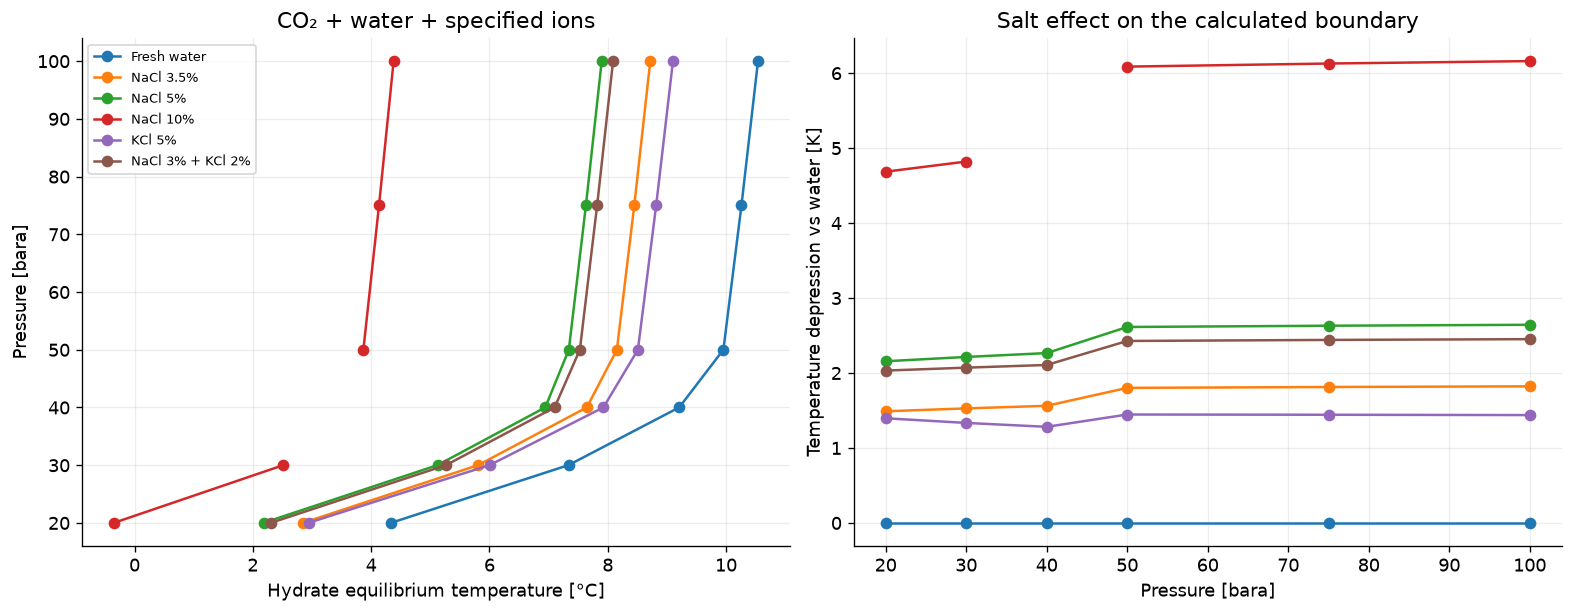

In [5]:
pressures_bara = np.array([20.0, 30.0, 40.0, 50.0, 75.0, 100.0])
curve_rows = []
curve_cache = {}
for case_name, salts in CASES.items():
    for pressure_bara in pressures_bara:
        result, fluid = hydrate_point(pressure_bara, salts)
        curve_rows.append({
            "case": case_name,
            **result,
            "raw_temperature_c": result["hydrate_temperature_c"],
            "hydrate_temperature_c": (
                result["hydrate_temperature_c"] if result["accepted"] else np.nan
            ),
        })
        if result["accepted"]:
            curve_cache[(case_name, float(pressure_bara))] = result["hydrate_temperature_c"]
    accepted_count = sum(row["accepted"] for row in curve_rows if row["case"] == case_name)
    print(f"Completed {case_name}: {accepted_count}/{len(pressures_bara)} accepted points.")
curves = pd.DataFrame(curve_rows)
temperature_table = curves.pivot(
    index="pressure_bara", columns="case", values="hydrate_temperature_c"
).reindex(columns=list(CASES))
display(temperature_table.round(3).rename_axis("Pressure [bara]"))
rejected_curve_points = curves.loc[~curves["accepted"]].copy()
if not rejected_curve_points.empty:
    print("Rejected points: NaN values create gaps in the curves; no interpolation across them.")
    display(rejected_curve_points[[
        "case", "pressure_bara", "raw_temperature_c", "phases", "hydrate_residual"
    ]])

figure, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
for case_name in CASES:
    temperatures = temperature_table[case_name]
    axes[0].plot(temperatures, pressures_bara, "o-", label=case_name)
    depression = temperature_table["Fresh water"] - temperatures
    axes[1].plot(pressures_bara, depression, "o-", label=case_name)
axes[0].set(xlabel="Hydrate equilibrium temperature [°C]", ylabel="Pressure [bara]")
axes[0].set_title("CO₂ + water + specified ions")
axes[1].set(xlabel="Pressure [bara]", ylabel="Temperature depression vs water [K]")
axes[1].set_title("Salt effect on the calculated boundary")
axes[0].legend(fontsize=8, loc="upper left")
show_figure(figure, "01_hydrate_curves")

### Water activity at a common temperature and pressure

Water activity must be compared at the same state. We flash all brines at **15 °C and 50 bara**,
then divide their aqueous water fugacity by the pure-liquid-water reference from the same model.
Dissolved CO₂ also affects water activity; the fresh-water case contains CO₂, whereas the reference
state used in the denominator contains only water.

This is a model output. A measured mud-filtrate water activity would be an independent validation
quantity. It cannot be passed to the hydrate flash as an arbitrary multiplier without a consistent
reference state and a documented thermodynamic extension.

,Case,Water activity [-],Dissolved molecular CO2 [mol%]
0,Fresh water,0.97662,2.57944
1,NaCl 3.5%,0.95716,2.39964
2,NaCl 5%,0.94842,2.32294
3,NaCl 10%,0.91537,2.07255
4,KCl 5%,0.96059,4.68749
5,NaCl 3% + KCl 2%,0.95045,3.11785


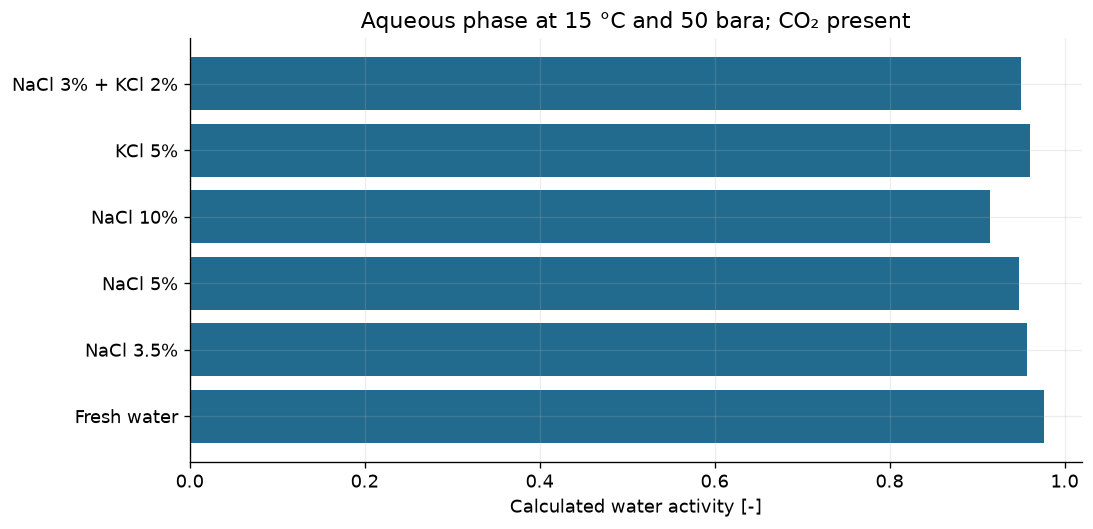

In [6]:
reference_water = FluidClass(288.15, 50.0)
reference_water.addComponent("water", WATER_KG / MOLAR_MASS_WATER)
reference_water.setMixingRule(10)
Operations(reference_water).TPflash()
reference_water_fugacity = reference_water.getPhase(0).getFugacity("water")
activity_rows = []
for case_name, salts in CASES.items():
    fluid = make_fluid(50.0, salts)
    fluid.setTemperature(288.15)
    Operations(fluid).TPflash()
    aqueous = fluid.getPhase("aqueous")
    activity_rows.append({
        "Case": case_name,
        "Water activity [-]": aqueous.getFugacity("water") / reference_water_fugacity,
        "Dissolved molecular CO2 [mol%]": aqueous.getComponent("CO2").getx() * 100.0,
    })
activity_table = pd.DataFrame(activity_rows)
display(activity_table.round(5))
figure, axis = plt.subplots(figsize=(9, 4.3), layout="constrained")
axis.barh(activity_table["Case"], activity_table["Water activity [-]"], color="#236b8e")
axis.set(xlabel="Calculated water activity [-]", xlim=(0, 1.02))
axis.set_title("Aqueous phase at 15 °C and 50 bara; CO₂ present")
show_figure(figure, "02_water_activity")

## 6. Combined NaCl and MEG inhibition

The salt recipe is fixed at 5 wt% on water-plus-salt. MEG is varied on water-plus-MEG.
The output table makes both bases visible. This avoids the common error of interpreting mud wt%,
liquid-phase wt%, water-basis dosage and mole fraction as interchangeable.

The calculation returns an equilibrium shift. A kinetic inhibitor is not equivalent to MEG,
and a polymer concentration must not be substituted for MEG concentration.

,MEG in water+MEG [wt%],Salt in water+salt+MEG [wt%],MEG in water+salt+MEG [wt%],Pressure [bara],Hydrate temperature [°C]
0,0.0,5.000,0.000,50.0,7.341
1,0.0,5.000,0.000,100.0,7.897
2,5.0,4.762,4.762,50.0,5.503
3,5.0,4.762,4.762,100.0,6.042
4,10.0,4.523,9.548,50.0,3.487
5,10.0,4.523,9.548,100.0,3.946
6,20.0,4.040,19.192,50.0,-1.161
7,20.0,4.040,19.192,100.0,-0.652


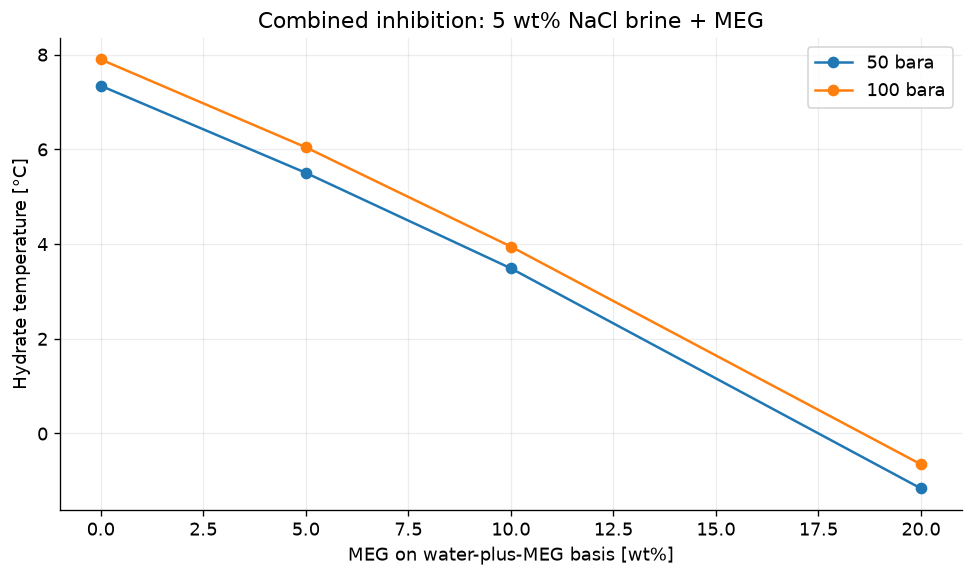

In [7]:
meg_rows = []
for meg_wt_percent in [0.0, 5.0, 10.0, 20.0]:
    inventory, meg_mass_kg = recipe_inventory({"NaCl": 5.0}, meg_wt_percent)
    salt_mass_kg = sum(row["mass_kg"] for row in inventory)
    liquid_mass_kg = WATER_KG + salt_mass_kg + meg_mass_kg
    for pressure_bara in [50.0, 100.0]:
        result, fluid = hydrate_point(
            pressure_bara, {"NaCl": 5.0}, meg_wt_percent=meg_wt_percent
        )
        assert result["accepted"], result
        meg_rows.append({
            "MEG in water+MEG [wt%]": meg_wt_percent,
            "Salt in water+salt+MEG [wt%]": 100.0 * salt_mass_kg / liquid_mass_kg,
            "MEG in water+salt+MEG [wt%]": 100.0 * meg_mass_kg / liquid_mass_kg,
            "Pressure [bara]": pressure_bara,
            "Hydrate temperature [°C]": result["hydrate_temperature_c"],
        })
meg_table = pd.DataFrame(meg_rows)
display(meg_table.round(3))
figure, axis = plt.subplots(figsize=(8, 4.7), layout="constrained")
for pressure_bara, group in meg_table.groupby("Pressure [bara]"):
    axis.plot(
        group["MEG in water+MEG [wt%]"], group["Hydrate temperature [°C]"],
        "o-", label=f"{pressure_bara:.0f} bara",
    )
axis.set(xlabel="MEG on water-plus-MEG basis [wt%]", ylabel="Hydrate temperature [°C]")
axis.set_title("Combined inhibition: 5 wt% NaCl brine + MEG")
axis.legend()
show_figure(figure, "03_meg_sensitivity")

## 7. Guest composition: CO₂ with a methane impurity

The two feeds contain 10 mol total guest molecules per kg water. The mixture is 90 mol% CO₂
and 10 mol% CH₄ **on the dry incoming guest basis**. Dissolution changes the CO₂-rich phase
composition; this is why the equilibrium composition is also displayed.

Hydrate equilibrium depends on guest fugacities, not simply CO₂ partial pressure. The mixture
may move the boundary in a direction that cannot be inferred from CO₂ dilution alone.

,Guest feed,Pressure [bara],Hydrate temperature [°C],CO2-rich phase CO2 [mol%]
0,100% CO2 feed,20.0,2.180,99.953
1,90% CO2 + 10% CH4 feed,20.0,1.811,89.142
2,100% CO2 feed,50.0,7.341,99.797
3,90% CO2 + 10% CH4 feed,50.0,8.138,88.468
4,100% CO2 feed,100.0,7.897,99.767
5,90% CO2 + 10% CH4 feed,100.0,10.593,88.718


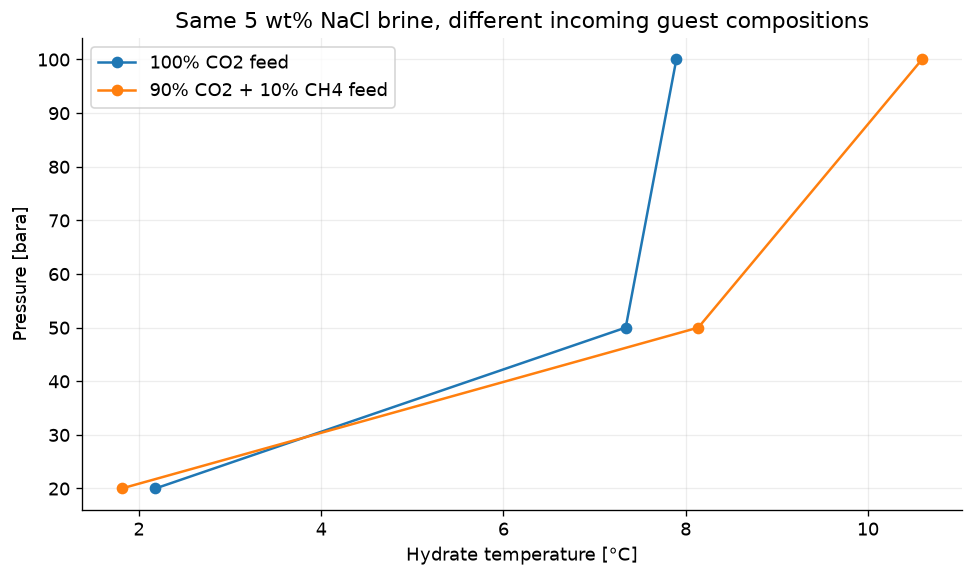

In [8]:
guest_rows = []
for pressure_bara in [20.0, 50.0, 100.0]:
    for guest_name, gas_amounts in {
        "100% CO2 feed": {"CO2": 10.0},
        "90% CO2 + 10% CH4 feed": {"CO2": 9.0, "methane": 1.0},
    }.items():
        result, fluid = hydrate_point(pressure_bara, {"NaCl": 5.0}, gas_amounts=gas_amounts)
        assert result["accepted"], result
        rich_phase = next(
            fluid.getPhase(index) for index in range(fluid.getNumberOfPhases())
            if str(fluid.getPhase(index).getType()) != "AQUEOUS"
        )
        guest_rows.append({
            "Guest feed": guest_name,
            "Pressure [bara]": pressure_bara,
            "Hydrate temperature [°C]": result["hydrate_temperature_c"],
            "CO2-rich phase CO2 [mol%]": rich_phase.getComponent("CO2").getx() * 100.0,
        })
guest_table = pd.DataFrame(guest_rows)
display(guest_table.round(3))
figure, axis = plt.subplots(figsize=(8, 4.7), layout="constrained")
for guest_name, group in guest_table.groupby("Guest feed"):
    axis.plot(group["Hydrate temperature [°C]"], group["Pressure [bara]"], "o-", label=guest_name)
axis.set(xlabel="Hydrate temperature [°C]", ylabel="Pressure [bara]")
axis.set_title("Same 5 wt% NaCl brine, different incoming guest compositions")
axis.legend()
show_figure(figure, "04_guest_composition")

## 8. CO₂ availability, aqueous chemistry and model limits

### 8.1 Saturated versus finite dissolved-CO₂ inventory

A brine in contact with a CO₂-rich phase is different from a closed liquid containing only a
limited amount of dissolved CO₂. Compare 1 and 10 mol CO₂ per kg water at 100 bara, both with
5 wt% NaCl. The single-aqueous result is shown as an **unqualified finite-inventory screen**,
not included in the saturated curves or used to train the mud correlation.

Burgass et al. (2023) report separate measurements for undersaturated systems. Their results
support the need to distinguish these inventories; they do not validate this NeqSim result.
The current phase-state limitations are tracked in
[NeqSim issue #3584](https://github.com/equinor/neqsim/issues/3584).

In [9]:
inventory_rows = []
for co2_moles in [1.0, 10.0]:
    result, fluid = hydrate_point(
        100.0, {"NaCl": 5.0}, gas_amounts={"CO2": co2_moles}, require_co2_phase=False
    )
    assert result["accepted"], result
    inventory_rows.append({
        "CO2 [mol/kg water]": co2_moles,
        "Calculated boundary [°C]": result["hydrate_temperature_c"],
        "Material phases": result["phases"],
        "Use": (
            "Saturated brine screen" if result["co2_rich_phase"]
            else "Finite-inventory screen; not qualified"
        ),
    })
inventory_table = pd.DataFrame(inventory_rows)
display(inventory_table.round(4))

,CO2 [mol/kg water],Calculated boundary [°C],Material phases,Use
0,1.0,5.6105,AQUEOUS,Finite-inventory screen; not qualified
1,10.0,7.8972,GAS+AQUEOUS,Saturated brine screen


### 8.2 Coupled CO₂–water chemical equilibrium

Enabling reactions adds acid/base speciation. We initialize the reaction set before the database
and mixing rule, then use the same hydrate operation. A near-boundary starting temperature
reduces unnecessary reactive flashes.

This example is **unbuffered CO₂–NaCl water**. A real alkaline drilling fluid may require carbonate,
bicarbonate, other counterions and reactive solids; its pH must not be inferred from this example.
The reported pH is the model's pH convention. Validate it against an appropriate measurement
method before using it for chemistry or materials decisions.

In [10]:
reactive_result, reactive_fluid = hydrate_point(
    100.0,
    {"NaCl": 5.0},
    reactive=True,
    initial_temperature_c=curve_cache[("NaCl 5%", 100.0)],
)
assert reactive_result["accepted"], reactive_result
reactive_aqueous = reactive_fluid.getPhase("aqueous")
chemistry_rows = []
for name in ["CO2", "HCO3-", "CO3--", "H3O+", "OH-", "Na+", "Cl-"]:
    if reactive_aqueous.hasComponent(name):
        chemistry_rows.append({
            "Species": name,
            "Aqueous mole fraction": reactive_aqueous.getComponent(name).getx(),
        })
chemistry_table = pd.DataFrame(chemistry_rows)
display(chemistry_table)


def recovered_component_moles(fluid, name):
    if not fluid.getPhase(0).hasComponent(name):
        return 0.0
    recovered_fraction = sum(
        fluid.getPhase(index).getBeta() * fluid.getPhase(index).getComponent(name).getx()
        for index in range(fluid.getNumberOfPhases())
    )
    return fluid.getNumberOfMoles() * recovered_fraction


recovered_carbon_moles = sum(
    recovered_component_moles(reactive_fluid, name) for name in ["CO2", "HCO3-", "CO3--"]
)
carbon_error_mol = abs(recovered_carbon_moles - 10.0)
chemistry_summary = pd.DataFrame([{
    "Non-reactive boundary [°C]": curve_cache[("NaCl 5%", 100.0)],
    "Reactive boundary [°C]": reactive_result["hydrate_temperature_c"],
    "Model pH [-]": reactive_aqueous.getpH(),
    "Carbon inventory error [mol]": carbon_error_mol,
    "Aqueous charge error [-]": reactive_result["charge_error"],
}])
display(chemistry_summary)

,Species,Aqueous mole fraction
0,CO2,2.540382e-02
1,HCO3-,1.404058e-04
2,CO3--,3.529924e-15
3,H3O+,1.404058e-04
4,OH-,1.232382e-14
5,Na+,1.532037e-02
6,Cl-,1.532037e-02


,Non-reactive boundary [°C],Reactive boundary [°C],Model pH [-],Carbon inventory error [mol],Aqueous charge error [-]
0,7.897177,7.951423,3.969228,2.000498e-10,5.106201e-12


### 8.3 A rejected high-pressure case: why the phase checks matter

At 200 bara, 10 wt% NaCl and the default 10 mol CO₂/kg water inventory, the inspected NeqSim
snapshot can return a small hydrate residual while retaining only an aqueous material phase.
This result is **rejected for use as a saturated CO₂–brine boundary** and is excluded from every
curve, benchmark, correlation and operating-margin calculation.

The raw returned temperature is retained for reproducibility of issue #3584. It is not an
approved equilibrium result. The root cause needs phase-stability investigation. Do not
extrapolate the principal 20–100 bara demonstration across this limitation.

In [11]:
high_pressure_diagnostic, diagnostic_fluid = hydrate_point(200.0, {"NaCl": 10.0})
diagnostic_table = pd.DataFrame([{
    "Pressure [bara]": high_pressure_diagnostic["pressure_bara"],
    "Raw returned temperature [°C]": high_pressure_diagnostic["hydrate_temperature_c"],
    "Material phases": high_pressure_diagnostic["phases"],
    "Hydrate residual [-]": high_pressure_diagnostic["hydrate_residual"],
    "Accepted as saturated boundary": high_pressure_diagnostic["accepted"],
}])
display(diagnostic_table)
print("This diagnostic is excluded from all engineering prediction tables.")

This diagnostic is excluded from all engineering prediction tables.


,Pressure [bara],Raw returned temperature [°C],Material phases,Hydrate residual [-],Accepted as saturated boundary
0,200.0,12.172422,AQUEOUS,-1.909758e-07,False


### 8.4 A rejected divalent-salt case: material balance is a separate requirement

The API accepts Ca²⁺, but that alone does not qualify a CaCl₂ calculation. For 3 wt% NaCl plus
0.6 wt% CaCl₂ at 50 bara, this source snapshot returns a small hydrate residual and a material
balance error in CO₂ and water. The ions remain charge balanced. This state is **rejected** and
excluded from every predictive curve and correlation. The main mixed-brine example uses NaCl–KCl.

[NeqSim issue #3585](https://github.com/equinor/neqsim/issues/3585) records the reproducible case
and the passing monovalent-salt control. Its raw temperature below is a solver diagnostic,
not a qualified CaCl₂ hydrate boundary.

In [12]:
calcium_diagnostic, calcium_fluid = hydrate_point(50.0, {"NaCl": 3.0, "CaCl2": 0.6})
calcium_balance_rows = []
for name in ["CO2", "water", "Na+", "Ca++", "Cl-"]:
    original_fraction = calcium_fluid.getPhase(0).getComponent(name).getz()
    recovered_fraction = sum(
        calcium_fluid.getPhase(index).getBeta()
        * calcium_fluid.getPhase(index).getComponent(name).getx()
        for index in range(calcium_fluid.getNumberOfPhases())
    )
    calcium_balance_rows.append({
        "Component": name,
        "Original overall mole fraction": original_fraction,
        "Reconstructed mole fraction": recovered_fraction,
        "Difference [-]": recovered_fraction - original_fraction,
    })
calcium_balance_table = pd.DataFrame(calcium_balance_rows)
display(calcium_balance_table)
display(pd.DataFrame([{
    "Raw solver temperature [°C]": calcium_diagnostic["hydrate_temperature_c"],
    "Hydrate residual [-]": calcium_diagnostic["hydrate_residual"],
    "Maximum component error [-]": calcium_diagnostic["balance_error"],
    "Accepted as boundary": calcium_diagnostic["accepted"],
}]))

,Component,Original overall mole fraction,Reconstructed mole fraction,Difference [-]
0,CO2,0.149831,0.147497,-0.002334
1,water,0.831691,0.834025,0.002334
2,Na+,0.007978,0.007978,0.000000
3,Ca++,0.000840,0.000840,0.000000
4,Cl-,0.009659,0.009659,0.000000


,Raw solver temperature [°C],Hydrate residual [-],Maximum component error [-],Accepted as boundary
0,8.429344,8.204050e-07,0.002334,False


## 9. Independent published-data comparison

The ten numerical points below are transcribed from **Table 4 of Burgass et al. (2023)**,
*CO₂ hydrate formation in NaCl systems and undersaturated aqueous solutions*,
[DOI: 10.2516/stet/2023005](https://doi.org/10.2516/stet/2023005).
The article is CC BY 4.0; attribution is retained here. The original pressure unit is MPa,
converted using 1 MPa = 10 bar, and temperature is converted from K to °C.

These points describe a CO₂-rich phase, liquid water/brine and hydrate. We use a sufficient CO₂
inventory and verify both material phases. The measured final gas/water inventory is not
reconstructed. This is a **limited external benchmark**, separate from the synthetic mud data.
No hydrate or electrolyte parameters are fitted here.

The paper reports expanded uncertainties of 0.4 K and 0.13 MPa with coverage factor 2.
The residual plot shows the temperature uncertainty for orientation; it does not combine pressure,
composition or model uncertainty. No paper-specific model accuracy is attributed to NeqSim.

External benchmark, n=10: MAE=0.143 K; RMSE=0.186 K; max |error|=0.393 K


,NaCl_wt_percent,pressure_bara,measured_temperature_c,neqsim_temperature_c,residual_K
0,5.0,11.49,-2.45,-2.2412,0.2088
1,5.0,17.36,1.05,1.0841,0.0341
2,5.0,21.80,2.75,2.8328,0.0828
3,5.0,25.99,4.15,4.1216,-0.0284
4,5.0,32.43,5.75,5.6430,-0.1070
5,5.0,42.26,7.45,7.2532,-0.1968
6,10.0,9.94,-6.25,-5.8575,0.3925
7,10.0,13.90,-3.45,-3.1554,0.2946
8,10.0,18.82,-0.85,-0.8055,0.0445
9,10.0,24.79,1.25,1.2129,-0.0371


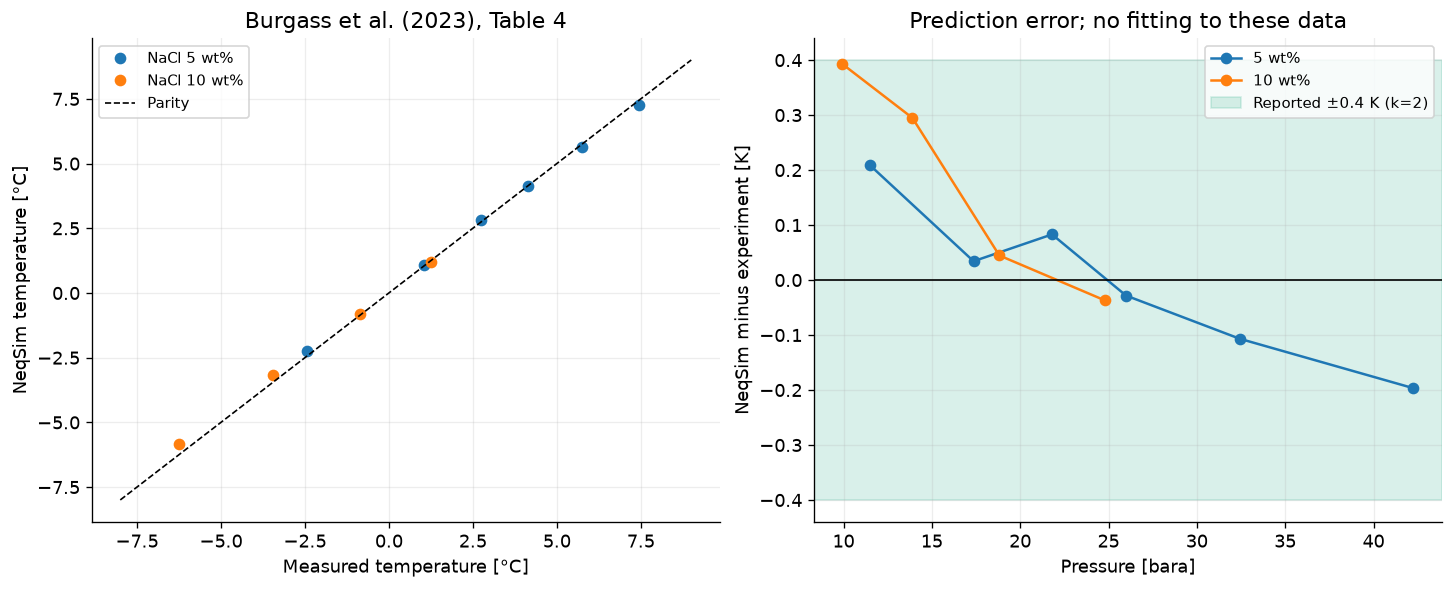

In [13]:
published = pd.DataFrame(
    [
        [5.0, 270.7, 1.149],
        [5.0, 274.2, 1.736],
        [5.0, 275.9, 2.180],
        [5.0, 277.3, 2.599],
        [5.0, 278.9, 3.243],
        [5.0, 280.6, 4.226],
        [10.0, 266.9, 0.994],
        [10.0, 269.7, 1.390],
        [10.0, 272.3, 1.882],
        [10.0, 274.4, 2.479],
    ],
    columns=["NaCl_wt_percent", "temperature_K", "pressure_MPa"],
)
published["pressure_bara"] = published["pressure_MPa"] * 10.0
published["measured_temperature_c"] = published["temperature_K"] - 273.15
benchmark_predictions = []
for row in published.itertuples():
    result, fluid = hydrate_point(row.pressure_bara, {"NaCl": row.NaCl_wt_percent})
    assert result["accepted"], result
    benchmark_predictions.append(result["hydrate_temperature_c"])
published["neqsim_temperature_c"] = benchmark_predictions
published["residual_K"] = (
    published["neqsim_temperature_c"] - published["measured_temperature_c"]
)
benchmark_mae_K = float(published["residual_K"].abs().mean())
benchmark_rmse_K = float(np.sqrt(np.mean(published["residual_K"] ** 2)))
benchmark_max_error_K = float(published["residual_K"].abs().max())
display(published[[
    "NaCl_wt_percent", "pressure_bara", "measured_temperature_c",
    "neqsim_temperature_c", "residual_K",
]].round(4))
print(f"External benchmark, n={len(published)}: MAE={benchmark_mae_K:.3f} K; "
      f"RMSE={benchmark_rmse_K:.3f} K; max |error|={benchmark_max_error_K:.3f} K")

figure, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")
for salinity, group in published.groupby("NaCl_wt_percent"):
    axes[0].plot(
        group["measured_temperature_c"], group["neqsim_temperature_c"],
        "o", label=f"NaCl {salinity:.0f} wt%",
    )
    axes[1].plot(group["pressure_bara"], group["residual_K"], "o-", label=f"{salinity:.0f} wt%")
limits = [-8.0, 9.0]
axes[0].plot(limits, limits, "k--", linewidth=1, label="Parity")
axes[0].set(xlabel="Measured temperature [°C]", ylabel="NeqSim temperature [°C]")
axes[0].set_title("Burgass et al. (2023), Table 4")
axes[0].legend(fontsize=9)
axes[1].axhspan(-0.4, 0.4, color="#009e73", alpha=0.15, label="Reported ±0.4 K (k=2)")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(xlabel="Pressure [bara]", ylabel="NeqSim minus experiment [K]")
axes[1].set_title("Prediction error; no fitting to these data")
axes[1].legend(fontsize=9)
show_figure(figure, "05_published_benchmark")

## 10. A brine baseline plus a laboratory correction for one mud family

A practical empirical model can preserve the brine calculation and fit only a discrepancy:

$$T_{mud}(P,c)=T_{brine}(P)+b_0+b_1c+b_2c\ln(P/P_{ref})$$

For this teaching example, $P_{ref}=50$ bara and $c$ is polymer dosage divided by
10 g/kg water, so $c$ is dimensionless and every $b_j$ has units K. The equation is an
**illustrative statistical choice**, not a published polymer-inhibition law. A fitted offset
can include additive effects and brine-model bias; it does not identify a causal mechanism.

**All observations generated in the next cell are SYNTHETIC.** Their purpose is to demonstrate
fitting, held-out validation, prediction intervals, domain checks and data export. Their good
fit must never be presented as accuracy on real laboratory measurements.

The scope is deliberately one NaCl concentration (5 wt%), one gas composition (pure CO₂),
one recipe family, equilibrium dissociation measurements and no MEG. Replace the input using
`LAB_CSV_PATH` only after adapting and validating the schema for a real study. Retain independent
mud batches for external validation; holding out pressure levels here does not test batch transfer.

In [14]:
LAB_CSV_PATH = None  # For real data, set this to an uploaded CSV path.
lab_pressures = [20.0, 30.0, 40.0, 50.0, 75.0, 100.0]
polymer_doses_g_kg = [0.0, 10.0, 20.0]
random_generator = np.random.default_rng(20260908)
synthetic_rows = []
for pressure_bara in lab_pressures:
    baseline_c = curve_cache[("NaCl 5%", pressure_bara)]
    for dose in polymer_doses_g_kg:
        scaled_dose = dose / 10.0
        imposed_shift_K = 0.25 - 0.70 * scaled_dose - 0.12 * scaled_dose * np.log(
            pressure_bara / 50.0
        )
        for replicate in [1, 2]:
            synthetic_rows.append({
                "fluid_family": "SYNTHETIC-MUD-A",
                "batch_id": f"SYNTHETIC-repeat-{replicate}",
                "pressure_bara": pressure_bara,
                "temperature_c": baseline_c + imposed_shift_K + random_generator.normal(0, 0.15),
                "NaCl_wt_percent": 5.0,
                "polymer_g_per_kg_water": dose,
                "u_temperature_K": 0.15,
                "guest_CO2_mole_fraction": 1.0,
                "MEG_wt_percent": 0.0,
                "method": "dissociation",
                "data_origin": "SYNTHETIC demonstration; not laboratory measurements",
            })
synthetic_lab = pd.DataFrame(synthetic_rows)
lab_data = synthetic_lab.copy() if LAB_CSV_PATH is None else pd.read_csv(LAB_CSV_PATH)
required_columns = list(synthetic_lab.columns)
assert set(required_columns).issubset(lab_data.columns)
assert lab_data[required_columns].notna().all().all()
assert lab_data["fluid_family"].nunique() == 1
assert np.allclose(lab_data["NaCl_wt_percent"], 5.0)
assert np.allclose(lab_data["guest_CO2_mole_fraction"], 1.0)
assert np.allclose(lab_data["MEG_wt_percent"], 0.0)
assert (lab_data["method"] == "dissociation").all()
assert lab_data["pressure_bara"].between(20.0, 100.0).all()
assert lab_data["polymer_g_per_kg_water"].between(0.0, 20.0).all()
assert (lab_data["u_temperature_K"] > 0).all()
using_synthetic_data = LAB_CSV_PATH is None
print("SYNTHETIC DATA — no project lab data" if using_synthetic_data else "USER-SUPPLIED DATA")
print(f"Rows: {len(lab_data)}; fluid family: {lab_data['fluid_family'].iloc[0]}")
display(lab_data[[
    "pressure_bara", "polymer_g_per_kg_water", "temperature_c", "u_temperature_K", "batch_id"
]].round(4))

SYNTHETIC DATA — no project lab data
Rows: 36; fluid family: SYNTHETIC-MUD-A


,pressure_bara,polymer_g_per_kg_water,temperature_c,u_temperature_K,batch_id
0,20.0,0.0,2.4160,0.15,SYNTHETIC-repeat-1
1,20.0,0.0,2.4658,0.15,SYNTHETIC-repeat-2
2,20.0,10.0,1.9116,0.15,SYNTHETIC-repeat-1
3,20.0,10.0,1.6818,0.15,SYNTHETIC-repeat-2
4,20.0,20.0,1.2201,0.15,SYNTHETIC-repeat-1
5,20.0,20.0,1.2132,0.15,SYNTHETIC-repeat-2
6,30.0,0.0,5.2873,0.15,SYNTHETIC-repeat-1
7,30.0,0.0,5.4008,0.15,SYNTHETIC-repeat-2
8,30.0,10.0,4.7144,0.15,SYNTHETIC-repeat-1
9,30.0,10.0,4.8130,0.15,SYNTHETIC-repeat-2


### Fit only on training pressure levels

All replicates at a given pressure are assigned together. The default training levels are
20, 40 and 75 bara; 30, 50 and 100 bara are held out. This prevents a replicate at the same
pressure and dosage from appearing in both sets. The highest held-out pressure is outside the
training-pressure range, so its result is explicitly an extrapolation test within the wider
demonstration domain. Pressure grouping is not a substitute for independent formulation batches.

Weighted least squares uses the stated standard temperature uncertainties. The residual scatter
estimated from the training data scales the coefficient covariance. Prediction intervals below
assume a correct linear discrepancy form and independent errors; they omit unmodelled chemistry,
recipe changes, phase-state failure and baseline-model uncertainty.

In [15]:
def brine_baseline(pressure_bara):
    key = ("NaCl 5%", float(pressure_bara))
    if key not in curve_cache:
        if not 20.0 <= pressure_bara <= 100.0:
            raise ValueError("Brine baseline is only demonstrated over 20–100 bara.")
        result, fluid = hydrate_point(pressure_bara, {"NaCl": 5.0})
        if not result["accepted"]:
            raise ValueError(f"Unqualified brine state: {result}")
        curve_cache[key] = result["hydrate_temperature_c"]
    return curve_cache[key]


def design_matrix(data):
    scaled_dose = data["polymer_g_per_kg_water"].to_numpy(dtype=float) / 10.0
    log_pressure = np.log(data["pressure_bara"].to_numpy(dtype=float) / 50.0)
    return np.column_stack([np.ones(len(data)), scaled_dose, scaled_dose * log_pressure])


lab_data["baseline_c"] = [brine_baseline(value) for value in lab_data["pressure_bara"]]
lab_data["split"] = np.where(lab_data["pressure_bara"].isin([20.0, 40.0, 75.0]), "train", "test")
training = lab_data.loc[lab_data["split"] == "train"].copy()
held_out = lab_data.loc[lab_data["split"] == "test"].copy()
assert len(training) > 3 and len(held_out) >= 3
assert set(training["pressure_bara"]).isdisjoint(set(held_out["pressure_bara"]))
training_design = design_matrix(training)
training_residual = (training["temperature_c"] - training["baseline_c"]).to_numpy()
standard_uncertainty = training["u_temperature_K"].to_numpy()
weighted_design = training_design / standard_uncertainty[:, None]
weighted_residual = training_residual / standard_uncertainty
coefficients, _, rank, _ = np.linalg.lstsq(weighted_design, weighted_residual, rcond=None)
assert rank == 3
fit_errors = training_residual - training_design @ coefficients
degrees_of_freedom = len(training) - rank
reduced_chi_square = np.sum((fit_errors / standard_uncertainty) ** 2) / degrees_of_freedom
coefficient_covariance = reduced_chi_square * np.linalg.inv(weighted_design.T @ weighted_design)
residual_scale_K = float(np.sqrt(np.sum(fit_errors ** 2) / degrees_of_freedom))
coefficient_table = pd.DataFrame({
    "Coefficient": ["b0 [K]", "b1 [K]", "b2 [K]"],
    "Estimate": coefficients,
    "Standard error": np.sqrt(np.diag(coefficient_covariance)),
})
display(coefficient_table.round(4))

lab_data["corrected_c"] = lab_data["baseline_c"] + design_matrix(lab_data) @ coefficients
lab_data["baseline_error_K"] = lab_data["baseline_c"] - lab_data["temperature_c"]
lab_data["corrected_error_K"] = lab_data["corrected_c"] - lab_data["temperature_c"]
metric_rows = []
for split_name, group in lab_data.groupby("split"):
    metric_rows.append({
        "Split": split_name,
        "Rows": len(group),
        "Brine RMSE [K]": np.sqrt(np.mean(group["baseline_error_K"] ** 2)),
        "Corrected RMSE [K]": np.sqrt(np.mean(group["corrected_error_K"] ** 2)),
    })
fit_metrics = pd.DataFrame(metric_rows)
display(fit_metrics.round(4))
print("These metrics describe synthetic-data recovery." if using_synthetic_data
      else "Validate transfer to independent batches before using this fit.")

These metrics describe synthetic-data recovery.


,Coefficient,Estimate,Standard error
0,b0 [K],0.2374,0.0338
1,b1 [K],-0.7411,0.0273
2,b2 [K],-0.1770,0.0307


,Split,Rows,Brine RMSE [K],Corrected RMSE [K]
0,test,18,0.7094,0.1826
1,train,18,0.7474,0.0829


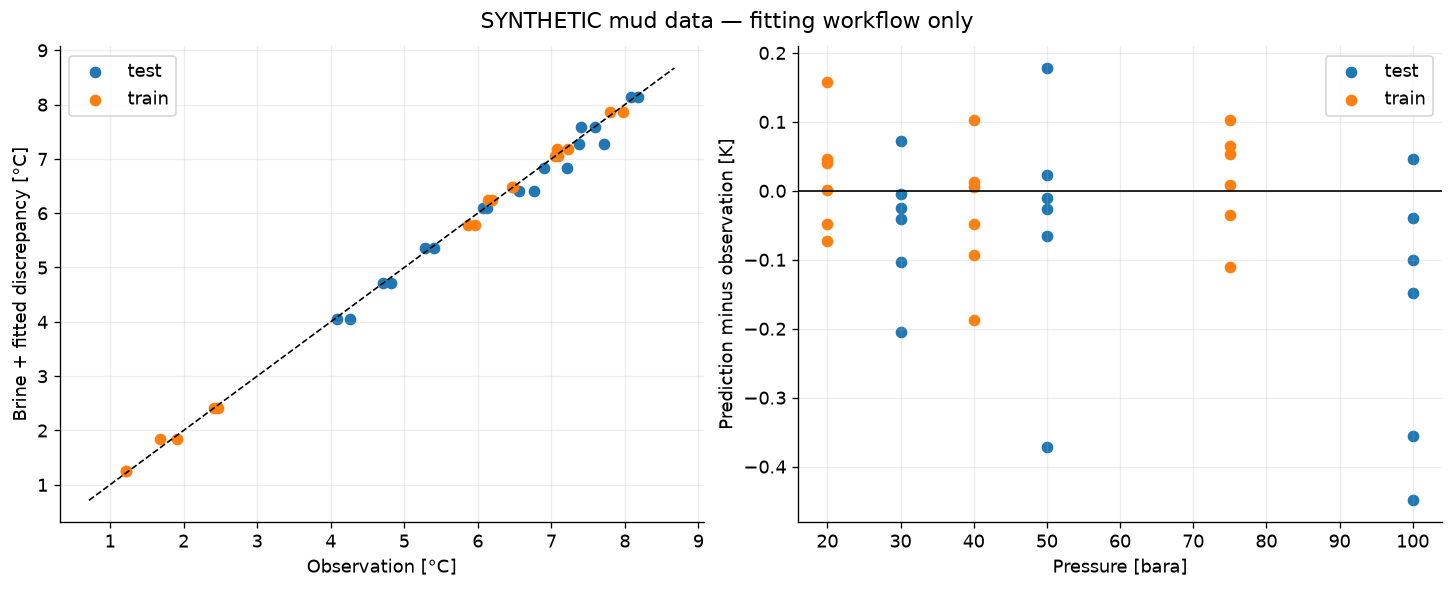

In [16]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")
for split_name, group in lab_data.groupby("split"):
    axes[0].scatter(group["temperature_c"], group["corrected_c"], label=split_name)
    axes[1].scatter(group["pressure_bara"], group["corrected_error_K"], label=split_name)
parity_limits = [lab_data["temperature_c"].min() - 0.5, lab_data["temperature_c"].max() + 0.5]
axes[0].plot(parity_limits, parity_limits, "k--", linewidth=1)
axes[0].set(xlabel="Observation [°C]", ylabel="Brine + fitted discrepancy [°C]")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(xlabel="Pressure [bara]", ylabel="Prediction minus observation [K]")
for axis in axes:
    axis.legend()
figure.suptitle("SYNTHETIC mud data — fitting workflow only" if using_synthetic_data
               else "User-supplied data — recipe-specific discrepancy model")
show_figure(figure, "06_synthetic_fit_validation")

## 11. Prediction interval and a temperature-margin screen

For one future observation with design row $\mathbf{x}_0$, the illustrative prediction interval is:

$$\widehat T_{mud}\pm t_{0.975,\nu}\sqrt{s^2+\mathbf{x}_0^T\operatorname{Cov}(\mathbf b)\mathbf{x}_0}$$

Here $s$ is training residual scatter in K and $\nu$ is the residual degrees of freedom.
The interval describes the statistical model, not total engineering uncertainty.

Define the temperature margin as:

$$\Delta T_{margin}=T_{operation}-T_{hydrate}$$

A negative margin means the assumed operating point lies below the selected equilibrium boundary.
**It is not a probability of hydrate formation.** The profile below is an illustrative list of
pressure/temperature states, not a wellbore hydraulics or transient calculation. The fitted
mud correction remains synthetic; it cannot justify an operational limit.

,Pressure [bara],Operating temperature [°C],Illustrative mud boundary [°C],95% prediction half-width [K],Nominal temperature margin [K],Margin to upper interval [K]
0,20.0,4.0,1.839,0.204,2.161,1.957
1,30.0,4.5,4.709,0.200,-0.209,-0.409
2,40.0,5.0,6.479,0.199,-1.479,-1.678
3,50.0,5.5,6.838,0.199,-1.338,-1.537
4,75.0,6.0,7.055,0.203,-1.055,-1.258
5,100.0,6.5,7.271,0.208,-0.771,-0.979


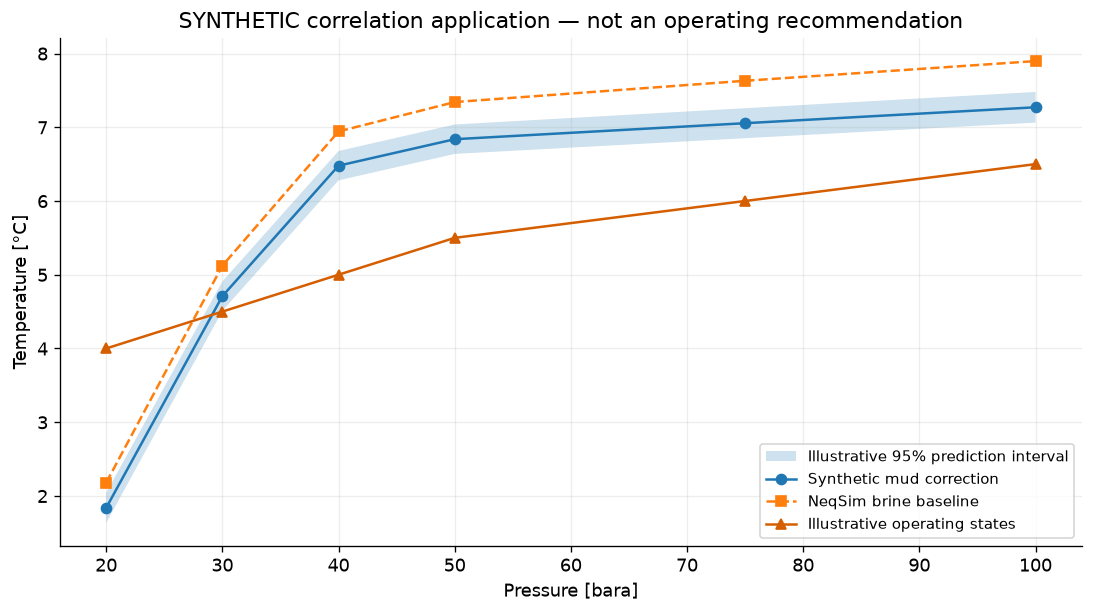

In [17]:
def corrected_prediction(pressure_bara, polymer_g_per_kg_water):
    if not 20.0 <= pressure_bara <= 100.0:
        raise ValueError("Pressure outside the demonstrated 20–100 bara domain.")
    if not 0.0 <= polymer_g_per_kg_water <= 20.0:
        raise ValueError("Polymer dosage outside the demonstrated 0–20 g/kg water domain.")
    point = pd.DataFrame([{
        "pressure_bara": pressure_bara,
        "polymer_g_per_kg_water": polymer_g_per_kg_water,
    }])
    row = design_matrix(point)[0]
    predicted_c = brine_baseline(pressure_bara) + float(row @ coefficients)
    variance_K2 = residual_scale_K ** 2 + float(row @ coefficient_covariance @ row)
    half_width_K = float(student_t.ppf(0.975, degrees_of_freedom) * np.sqrt(variance_K2))
    return predicted_c, half_width_K


operating_profile = pd.DataFrame({
    "Pressure [bara]": pressures_bara,
    "Operating temperature [°C]": [4.0, 4.5, 5.0, 5.5, 6.0, 6.5],
})
profile_predictions = [corrected_prediction(pressure, 10.0) for pressure in pressures_bara]
operating_profile["Illustrative mud boundary [°C]"] = [row[0] for row in profile_predictions]
operating_profile["95% prediction half-width [K]"] = [row[1] for row in profile_predictions]
operating_profile["Nominal temperature margin [K]"] = (
    operating_profile["Operating temperature [°C]"]
    - operating_profile["Illustrative mud boundary [°C]"]
)
operating_profile["Margin to upper interval [K]"] = (
    operating_profile["Nominal temperature margin [K]"]
    - operating_profile["95% prediction half-width [K]"]
)
display(operating_profile.round(3))
figure, axis = plt.subplots(figsize=(9, 5), layout="constrained")
predicted_values = operating_profile["Illustrative mud boundary [°C]"].to_numpy()
half_widths = operating_profile["95% prediction half-width [K]"].to_numpy()
axis.fill_between(
    pressures_bara, predicted_values - half_widths, predicted_values + half_widths,
    alpha=0.22, label="Illustrative 95% prediction interval",
)
axis.plot(pressures_bara, predicted_values, "o-", label="Synthetic mud correction")
axis.plot(pressures_bara, temperature_table["NaCl 5%"], "s--", label="NeqSim brine baseline")
axis.plot(
    pressures_bara, operating_profile["Operating temperature [°C]"],
    "^-", color="#d55e00", label="Illustrative operating states",
)
axis.set(xlabel="Pressure [bara]", ylabel="Temperature [°C]")
axis.set_title("SYNTHETIC correlation application — not an operating recommendation")
axis.legend(fontsize=9)
show_figure(figure, "07_temperature_margin")

## 12. Laboratory plan and data handoff

The empirical-correlation idea is useful if the experimental design separates the important effects.
A practical sequence is:

1. **Validate the base brine:** actual ion composition, matched concentration basis, CO₂-rich phase
   and several pressures on each side of the CO₂ gas/liquid transition.
2. **Compare brine, filtrate and whole mud:** hold dissolved salts and water mass constant; record
   polymer, solids, MEG, alkalinity, water activity and the history of each batch.
3. **Separate equilibrium and kinetics:** dissociation endpoints for equilibrium; separately record
   formation onset, hold times, stirring, hysteresis, nucleation and agglomeration observations.
4. **Vary CO₂ loading:** verify whether free CO₂ is present. Do not combine saturated boundaries and
   undersaturated dissolved-inventory measurements under a single salinity-only correlation.
5. **Fit and challenge the correction:** retain brine-model error, pressure/temperature uncertainty,
   repeatability and independent batches. Report where the model is interpolating or extrapolating.

The next cell writes an empty CSV template with the exact importer columns. Additional columns
for full ion analysis, filtrate activity, solids and endpoint history should accompany the real
laboratory dataset. An empty template contains no invented measurements.

In [18]:
lab_template = pd.DataFrame(columns=required_columns)
lab_template.to_csv(output_dir / "laboratory_input_template.csv", index=False)
display(pd.DataFrame({
    "Required CSV column": required_columns,
    "Meaning": [
        "Recipe family identifier", "Independent batch or repeat identifier",
        "Absolute pressure, bara", "Dissociation temperature, degrees C",
        "NaCl wt% on water-plus-salt basis", "Polymer mass, g/kg water",
        "Standard temperature uncertainty, K", "Dry incoming CO2 mole fraction",
        "MEG wt% on water-plus-MEG basis", "Endpoint method; this fitter requires dissociation",
        "Laboratory source or explicit synthetic label",
    ],
}))
print("Empty input template:", output_dir / "laboratory_input_template.csv")

Empty input template: co2_hydrate_results/laboratory_input_template.csv


,Required CSV column,Meaning
0,fluid_family,Recipe family identifier
1,batch_id,Independent batch or repeat identifier
2,pressure_bara,"Absolute pressure, bara"
3,temperature_c,"Dissociation temperature, degrees C"
4,NaCl_wt_percent,NaCl wt% on water-plus-salt basis
5,polymer_g_per_kg_water,"Polymer mass, g/kg water"
6,u_temperature_K,"Standard temperature uncertainty, K"
7,guest_CO2_mole_fraction,Dry incoming CO2 mole fraction
8,MEG_wt_percent,MEG wt% on water-plus-MEG basis
9,method,Endpoint method; this fitter requires dissocia...


## 13. Numerical validation and reproducibility

These checks cover the accepted demonstration domain, ion/charge/material conservation,
qualitative salt and MEG trends, reactive carbon inventory, independent starting temperatures,
held-out pressure separation and complete external-benchmark execution.

They do not convert a numerical screen into a validated drilling-fluid prediction. The
rejected phase-state and calcium-balance diagnostics are absent from the accepted-result pool. Repository
validation evidence records clean execution, source and dependency versions, retained outputs,
HTML/MathJax rendering and visual inspection.

In [19]:
seed_rows = []
for initial_temperature_c in [0.0, 12.0]:
    result, fluid = hydrate_point(50.0, {"NaCl": 5.0}, initial_temperature_c=initial_temperature_c)
    assert result["accepted"], result
    seed_rows.append({
        "Starting temperature [°C]": initial_temperature_c,
        "Calculated boundary [°C]": result["hydrate_temperature_c"],
        "Hydrate residual [-]": result["hydrate_residual"],
    })
seed_table = pd.DataFrame(seed_rows)
display(seed_table)
seed_spread_K = float(seed_table["Calculated boundary [°C]"].max()
                      - seed_table["Calculated boundary [°C]"].min())
accepted_runs = pd.DataFrame([row for row in all_runs if row["accepted"]])
checks = {
    "All 36 principal curve attempts recorded": len(curves) == 36,
    "20, 50 and 100 bara controls accepted for every recipe": bool(
        curves.loc[curves["pressure_bara"].isin([20.0, 50.0, 100.0]), "accepted"].all()
    ),
    "Accepted principal boundaries increase with pressure": all(
        np.all(np.diff(temperature_table[name].dropna()) > 0.0) for name in CASES
    ),
    "Rejected points excluded from principal temperature table": bool(
        curves.loc[~curves["accepted"], "hydrate_temperature_c"].isna().all()
    ),
    "NaCl concentration depresses each curve": bool(
        ((temperature_table["Fresh water"] > temperature_table["NaCl 3.5%"])
         & (temperature_table["NaCl 3.5%"] > temperature_table["NaCl 5%"])
         & (
             (temperature_table["NaCl 5%"] > temperature_table["NaCl 10%"])
             | temperature_table["NaCl 10%"].isna()
         )).all()
    ),
    "MEG depresses both pressure cases": all(
        np.all(np.diff(group["Hydrate temperature [°C]"]) < 0)
        for _, group in meg_table.groupby("Pressure [bara]")
    ),
    "Water activities finite and in (0,1]": bool(
        activity_table["Water activity [-]"].between(0.0, 1.0, inclusive="right").all()
    ),
    "Component inventory error below 1e-8": accepted_runs["balance_error"].max() < 1.0e-8,
    "Aqueous charge error below 1e-8": accepted_runs["charge_error"].max() < 1.0e-8,
    "Ions confined to aqueous phase": accepted_runs["ion_leak"].max() < 1.0e-15,
    "Reactive carbon error below 1e-6 mol": carbon_error_mol < 1.0e-6,
    "Starting-temperature spread below 0.002 K": seed_spread_K < 0.002,
    "All ten published points calculated": len(published) == 10 and np.isfinite(benchmark_rmse_K),
    "No pressure-level leakage in fitting": set(training["pressure_bara"]).isdisjoint(
        held_out["pressure_bara"]
    ),
    "High-pressure suspect state rejected": not high_pressure_diagnostic["accepted"],
    "Unbalanced NaCl-CaCl2 state rejected": not calcium_diagnostic["accepted"],
}
check_table = pd.DataFrame({"Check": checks.keys(), "Passed": [bool(v) for v in checks.values()]})
display(check_table)
failed = [name for name, passed in checks.items() if not passed]
assert not failed, failed
print(f"Passed {len(checks)} numerical/workflow checks; {len(accepted_runs)} accepted runs.")
print(f"Maximum component error: {accepted_runs['balance_error'].max():.3e}")
print(f"Maximum aqueous charge error: {accepted_runs['charge_error'].max():.3e}")
print(f"Maximum hydrate residual: {accepted_runs['hydrate_residual'].abs().max():.3e}")

Passed 16 numerical/workflow checks; 65 accepted runs.
Maximum component error: 9.043e-13
Maximum aqueous charge error: 5.106e-12
Maximum hydrate residual: 8.904e-07


,Starting temperature [°C],Calculated boundary [°C],Hydrate residual [-]
0,0.0,7.341477,2.556641e-07
1,12.0,7.341502,-2.685319e-08


,Check,Passed
0,All 36 principal curve attempts recorded,True
1,"20, 50 and 100 bara controls accepted for ever...",True
2,Accepted principal boundaries increase with pr...,True
3,Rejected points excluded from principal temper...,True
4,NaCl concentration depresses each curve,True
5,MEG depresses both pressure cases,True
6,"Water activities finite and in (0,1]",True
7,Component inventory error below 1e-8,True
8,Aqueous charge error below 1e-8,True
9,Ions confined to aqueous phase,True


## 14. Reuse the calculations: practice tasks and saved results

After running the notebook, add a code cell to repeat the single-point example:

```python
result, fluid = hydrate_point(50.0, {"NaCl": 5.0})
display(pd.DataFrame([result]))
```

Here pressure is **bara** and salt concentration is **wt% on water plus all salts**.
`result` contains the calculated temperature and acceptance diagnostics; `fluid` is the
NeqSim system whose phases and components you can inspect. Check `result["accepted"]`
before treating the returned temperature as an accepted saturated-boundary point.

**Try the following exercises:**

- Compare fresh water with 5 wt% NaCl at 50 bara using Section 4. Explain the temperature shift
  using the concentration basis and the water-activity discussion.
- Inspect `CASES` and `pressures_bara` in Sections 3 and 5. Add a salt concentration within the
  demonstrated range, restart and run all cells, then inspect its curve and acceptance diagnostics.
  Additional curve points also require updating the explicitly fixed-count checks in Section 13.
- Use Section 6 to compare 0, 5, 10 and 20 wt% MEG. Identify which concentration basis each
  output column uses and explain why the total-liquid salt fraction changes.
- Use Section 7 to compare the incoming and equilibrium CO₂ fractions. Explain why a feed
  specification alone does not describe the equilibrium CO₂-rich phase.
- Inspect the rejected states in Section 8. Explain why a small hydrate residual is insufficient.
- Follow Sections 10–12 to understand the synthetic fitting example, then inspect the empty
  laboratory-input template before adapting the workflow to measured data.

The files below are generated in `co2_hydrate_results/` in the current runtime. Every important
result is also displayed above. CSV files retain full numerical precision; presentation tables
are rounded. The diagnostics CSV includes every rejected state with an explicit acceptance flag.

Use the brine/inhibitor examples as a starting point for learning and method development.
A recipe-specific drilling-fluid correction requires measured filtrate and whole-mud data.
These examples do not establish a general equilibrium model for all water-based drilling fluids,
nor formation rates, plugging probability or operational safety.

In [20]:
export_tables = {
    "brine_curves.csv": curves,
    "water_activity.csv": activity_table,
    "meg_screen.csv": meg_table,
    "guest_composition_screen.csv": guest_table,
    "finite_inventory_screen.csv": inventory_table,
    "reactive_species.csv": chemistry_table,
    "published_nacl_benchmark.csv": published,
    "synthetic_lab_data.csv": synthetic_lab,
    "correlation_data_and_predictions.csv": lab_data,
    "correlation_coefficients.csv": coefficient_table,
    "illustrative_temperature_margin.csv": operating_profile,
    "all_calculation_diagnostics.csv": pd.DataFrame(all_runs),
    "rejected_calcium_component_balance.csv": calcium_balance_table,
    "validation_checks.csv": check_table,
}
for filename, table in export_tables.items():
    table.to_csv(output_dir / filename, index=False)
provenance.update({
    "curve_domain_bara": [20.0, 100.0],
    "model": "SystemElectrolyteCPAstatoil / mixing rule 10 / ComponentHydrateGF",
    "external_benchmark": {
        "doi": "10.2516/stet/2023005", "table": 4, "license": "CC BY 4.0",
        "points": len(published), "MAE_K": benchmark_mae_K, "RMSE_K": benchmark_rmse_K,
    },
    "synthetic_correlation": bool(using_synthetic_data),
    "numerical_checks_passed": len(checks),
    "known_phase_state_issue": "https://github.com/equinor/neqsim/issues/3584",
    "known_calcium_balance_issue": "https://github.com/equinor/neqsim/issues/3585",
})
(output_dir / "provenance.json").write_text(json.dumps(provenance, indent=2), encoding="utf-8")
display(pd.DataFrame([
    {"File": path.name, "Bytes": path.stat().st_size}
    for path in sorted(output_dir.iterdir()) if path.is_file()
]))
print(f"At 50 bara: fresh water {curve_cache[('Fresh water', 50.0)]:.3f} °C; "
      f"5 wt% NaCl {curve_cache[('NaCl 5%', 50.0)]:.3f} °C.")
print(f"Independent NaCl benchmark MAE: {benchmark_mae_K:.3f} K across ten points.")
print("Mud correction: SYNTHETIC demonstration; replace with laboratory evidence.")

At 50 bara: fresh water 9.954 °C; 5 wt% NaCl 7.341 °C.
Independent NaCl benchmark MAE: 0.143 K across ten points.
Mud correction: SYNTHETIC demonstration; replace with laboratory evidence.


,File,Bytes
0,01_hydrate_curves.png,152688
1,02_water_activity.png,45706
2,03_meg_sensitivity.png,84547
3,04_guest_composition.png,74568
4,05_published_benchmark.png,129955
5,06_synthetic_fit_validation.png,99662
6,07_temperature_margin.png,100424
7,all_calculation_diagnostics.csv,11519
8,brine_curves.csv,7151
9,correlation_coefficients.csv,179


## 15. Sources, limitations and next experiments

**Implementation and license**

- [NeqSim source](https://github.com/equinor/neqsim), source commit printed in Section 2.
- [Hydrate models and electrolyte CPA](https://github.com/equinor/neqsim/blob/master/docs/thermo/hydrate_models.md).
- [Hydrate flash operations](https://github.com/equinor/neqsim/blob/master/docs/thermodynamicoperations/hydrate_flash_operations.md).
- [Electrolyte hydrate regression tests](https://github.com/equinor/neqsim/blob/master/src/test/java/neqsim/thermo/system/ElectrolyteCPAHydrateEquilibriumTest.java).
- [Apache License 2.0](https://www.apache.org/licenses/LICENSE-2.0).

**Primary experimental literature**

- Burgass, R., Chapoy, A., Askvik, K. M., Neeraas, B. O. and Li, X. (2023).
  *CO₂ hydrate formation in NaCl systems and undersaturated aqueous solutions*.
  Science and Technology for Energy Transition 78, 8.
  [doi:10.2516/stet/2023005](https://doi.org/10.2516/stet/2023005).
  Table 4 supplies the ten-point benchmark; Table 5 concerns a distinct undersaturated regime.
- Jibril, A., Burgass, R. W., Chapoy, A. and Ahmadi, P. (2025).
  *CO₂ and CO₂-rich stream hydrate formation in equilibrium with brines in the context of CO₂ injection*.
  [doi:10.1021/acs.jced.5c00173](https://doi.org/10.1021/acs.jced.5c00173).
  A candidate source for extending mixed-salt and high-pressure qualification; no data from it are fitted here.
- Feneuil, B., N’Gouamba, E., Skogestad, J. O. and Linga, H. (2025).
  *Effect of dissolution of CO₂ and CH₄ on the flow curve of drilling fluids*.
  [Author paper, Nordic Rheology Society](https://journals.uis.no/index.php/tnrs/article/download/867/462/3041).
  This is relevant drilling-fluid context; it does not validate the NeqSim hydrate curves above.

**Tracked improvements**

- [#3584: CO₂–brine hydrate phase-state selection](https://github.com/equinor/neqsim/issues/3584):
  high-salinity/high-pressure and finite-CO₂ inventory qualification; structured residual/phase diagnostics.
- [#3585: NaCl–CaCl₂ component-inventory imbalance](https://github.com/equinor/neqsim/issues/3585):
  a divalent-salt state excluded by the explicit conservation check.
- [#3144: electrolyte thermodynamics and phase-behaviour roadmap](https://github.com/equinor/neqsim/issues/3144):
  salt parameters, hydrate/reactive coupling and broader public-benchmark validation.

**Suggested extensions after laboratory data are available**

- Replace the NaCl-only baseline with the measured complete ion analysis and verify charge balance.
- Compare equal molality as well as equal salt mass fraction; neither alone captures all specific-ion effects.
- Match initial versus final aqueous salinity and gas inventory to the experimental protocol.
- Quantify uncertainty from pressure, temperature, salinity, MEG and dissolved-CO₂ measurements.
- Reserve new production mud batches and different pressure ranges for independent validation.
- Extend pressure only after phase-state, freezing/solid and independent benchmark checks pass.

No kinetic constants, polymer EOS parameters, commercial-mud validation data or operational design
criteria have been invented. The disclosed synthetic correlation is an executable statistical example.